In [56]:
# load necessary libraries and disable some warnings
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers import AutoTokenizer
import torch
import umap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, normalized_mutual_info_score, adjusted_rand_score
from pathlib import Path

project_root = Path.cwd() / "../"
sys.path.append(str(project_root))

from utils.clustering import ModelMask, get_mask_embedding
from utils.preprocessing import create_regex_pattern

# load the dictionary terms
groups_dict_wide = pd.read_csv("../01_data/classification/dictionary/groups_dictionary_cl.csv")

In [57]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dict_wide.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dict_wide[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

category_list = [cat for cat in category_list]

groups_dict_long = pd.DataFrame({'mention': mention_list, 'category': category_list})

mention_list = groups_dict_long["mention"].to_list()
category_list = groups_dict_long["category"].to_list()

In [58]:
# load model from checkpoint
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = ModelMask(tokenizer).to(device)
model.load_state_dict(torch.load(f="model_checkpoint/checkpoint_50.pt", map_location=torch.device("mps")))

mention_embeddings = get_mask_embedding(model, mention_list, tokenizer, device)
labels_np = np.array([cat2id[cat] for cat in category_list])

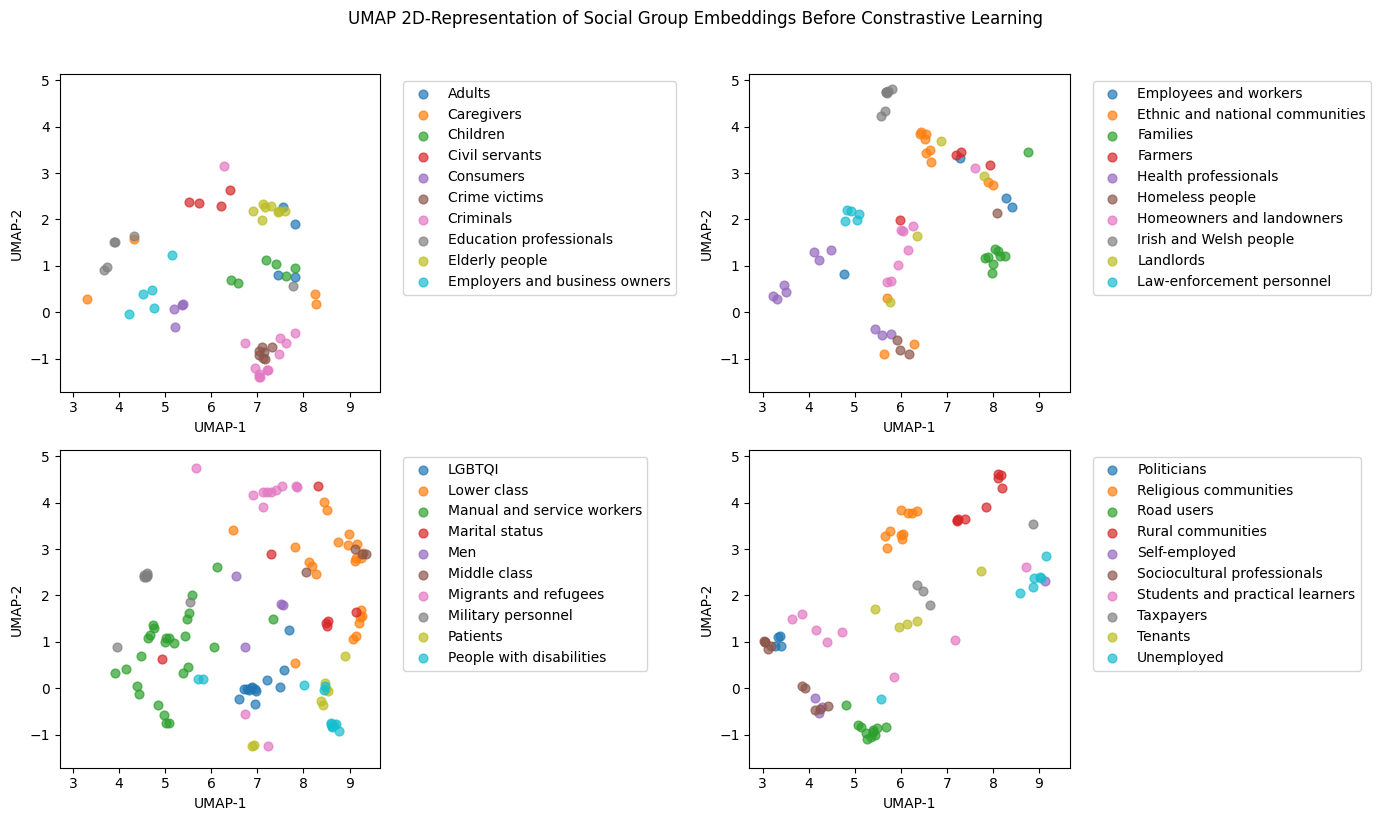

In [6]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model_without_cl = ModelMask(tokenizer).to(device)
emb_without_cl = get_mask_embedding(model_without_cl, mention_list, tokenizer, device)

reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(emb_without_cl)

x_min, x_max = emb_2d[:, 0].min(), emb_2d[:, 0].max()
y_min, y_max = emb_2d[:, 1].min(), emb_2d[:, 1].max()
pad = 0.05
x_range = x_max - x_min
y_range = y_max - y_min

categories = list(cat2id.keys())
num_classes = len(categories)

groups = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    for c in group:
        if c >= num_classes:
            continue
        idx = np.where(labels_np == c)[0]
        if len(idx) == 0:
            continue
        ax.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=categories[c],
            alpha=0.7,
            s=40
        )
    ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP 2D-Representation of Social Group Embeddings Before Constrastive Learning", y=1.02)
plt.tight_layout()
plt.show()

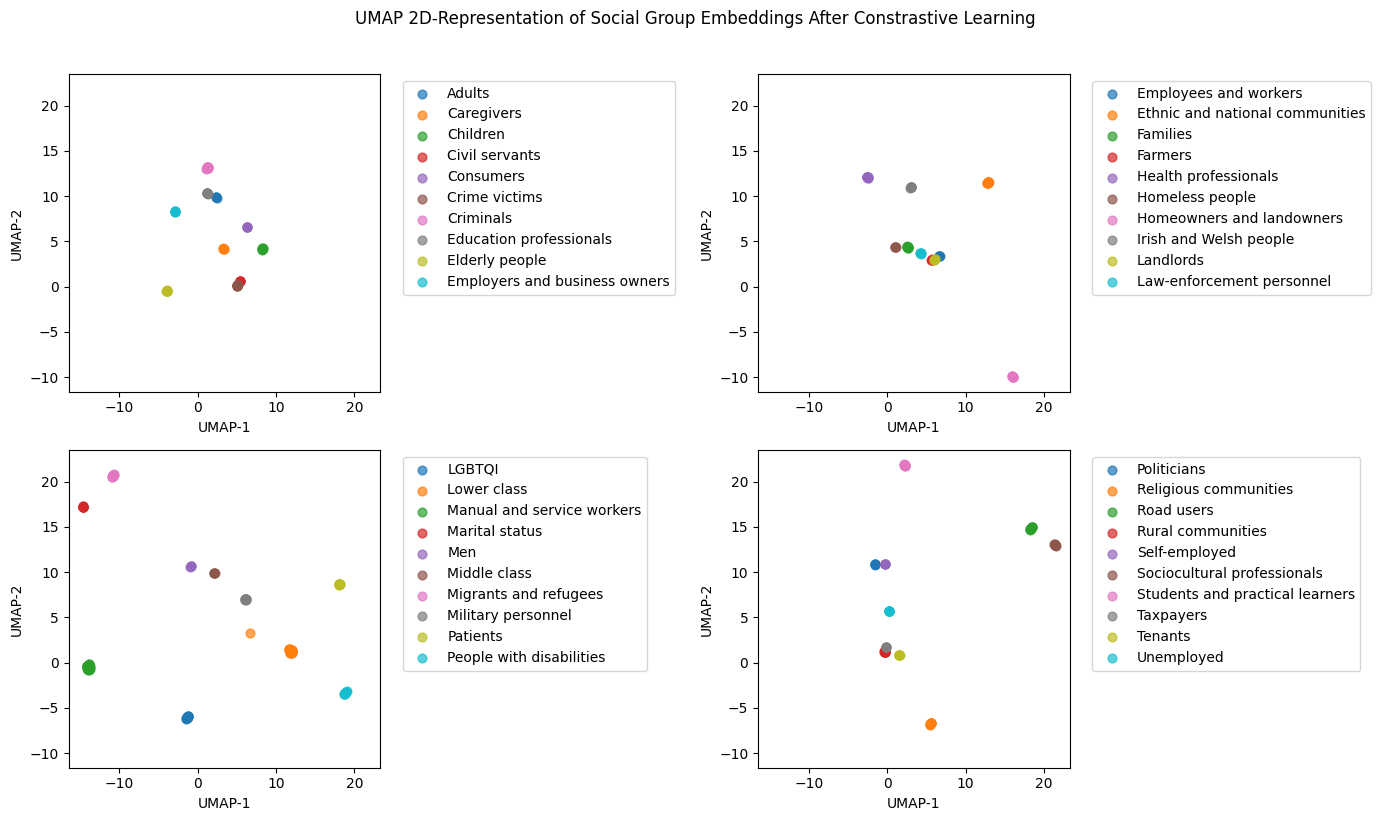

In [59]:
reducer = umap.UMAP(n_components=2)
emb_2d = reducer.fit_transform(mention_embeddings)

x_min, x_max = emb_2d[:, 0].min(), emb_2d[:, 0].max()
y_min, y_max = emb_2d[:, 1].min(), emb_2d[:, 1].max()
pad = 0.05
x_range = x_max - x_min
y_range = y_max - y_min

categories = list(cat2id.keys())
num_classes = len(categories)

groups = [
    range(0, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, group in zip(axes, groups):
    for c in group:
        if c >= num_classes:
            continue
        idx = np.where(labels_np == c)[0]
        if len(idx) == 0:
            continue
        ax.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            label=categories[c],
            alpha=0.7,
            s=40
        )
    ax.set_xlim(x_min - pad * x_range, x_max + pad * x_range)
    ax.set_ylim(y_min - pad * y_range, y_max + pad * y_range)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig.suptitle("UMAP 2D-Representation of Social Group Embeddings After Constrastive Learning", y=1.02)
plt.tight_layout()
plt.show()

Original number of categories: 45
Best k by BIC: 45


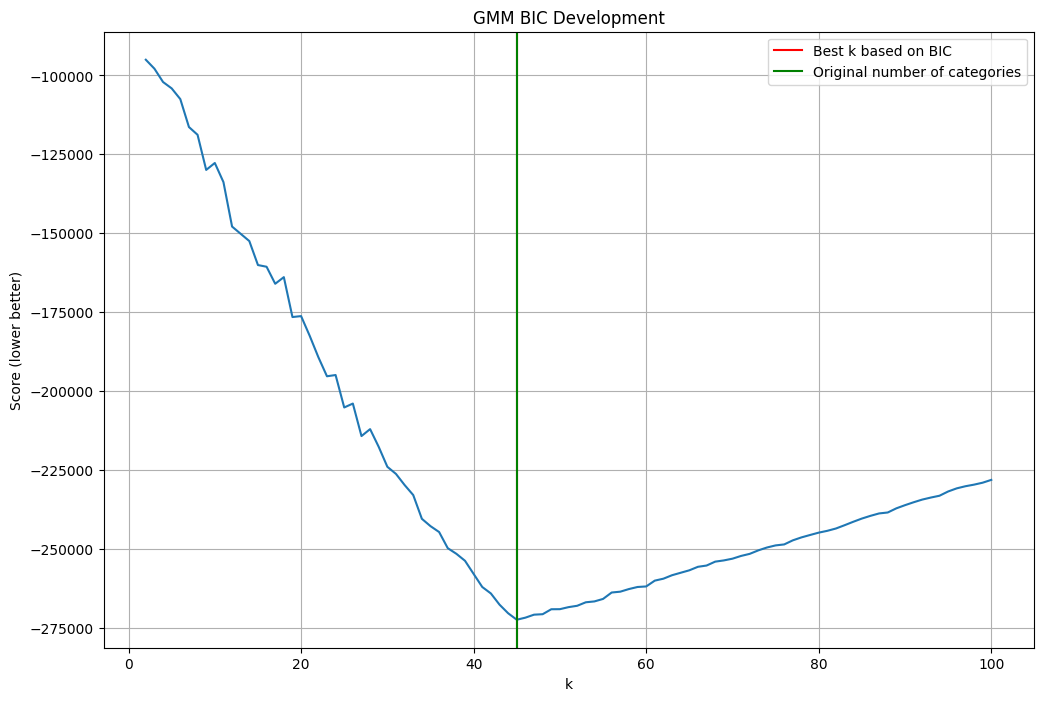

In [60]:
X = mention_embeddings.cpu().numpy()

ks = range(2, 101)
bics = []
cov_type = 'diag'
for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=7,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500
    )
    gmm.fit(X)
    bics.append(gmm.bic(X))

bics = np.array(bics)
best_idx = bics.argmin()
best_k = ks[best_idx]
print("Original number of categories: 45")
print("Best k by BIC:", best_k)

plt.figure(figsize=(12,8))
plt.plot(list(ks), bics)
plt.axvline(best_k, color="red", label="Best k based on BIC")
plt.axvline(45, color="green", label="Original number of categories")
plt.xlabel('k')
plt.ylabel('Score (lower better)')
plt.title(f'GMM BIC Development')
plt.legend()
plt.grid(True)
plt.show()

Original number of categories: 45
Best k by silhouette score: 45


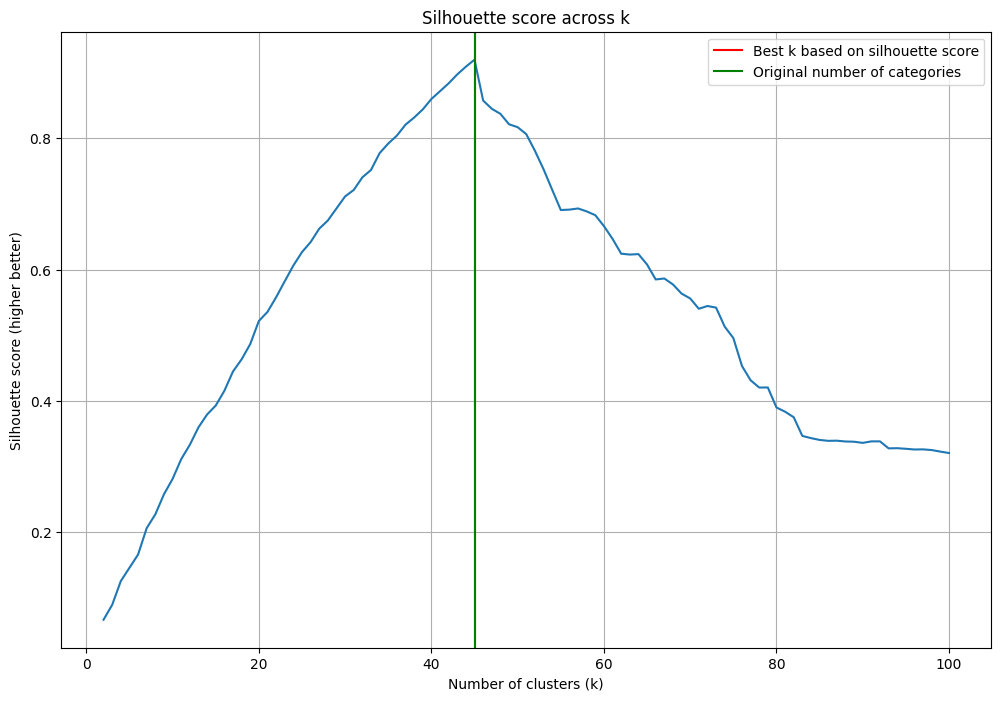

In [61]:
X = mention_embeddings.numpy()

ks = range(2, 101)

all_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X)
    all_scores.append(silhouette_score(X, pred_labels))

scores = np.array(all_scores)

best_idx = scores.argmax()
best_k = ks[best_idx]
best_score = scores[best_idx]

print("Original number of categories: 45")
print(f"Best k by silhouette score: {best_k}")

plt.figure(figsize=(12, 8))
plt.plot(list(ks), scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (higher better)")
plt.title("Silhouette score across k")
plt.grid(True)
plt.axvline(best_k, color="red", label="Best k based on silhouette score")
plt.axvline(45, color="green", label="Original number of categories")
plt.legend()
plt.show()

In [62]:
X = mention_embeddings.numpy()

k = len(set(categories))
kmeans = KMeans(n_clusters=k, random_state=42)

cluster_labels = kmeans.fit_predict(X)

cluster_labels = kmeans.labels_

groups_dict_long['cluster'] = cluster_labels

clusters = groups_dict_long['cluster'].unique()
cluster2cat = {c: groups_dict_long[groups_dict_long['cluster']==c]['category'].tolist() for c in clusters}
sorted_dict = dict(sorted(cluster2cat.items()))
sorted_dict

{0: ['LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI',
  'LGBTQI'],
 1: ['White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers',
  'White collar workers'],
 2: ['Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees',
  'Migrants and refugees'],
 3: ['Ethnic and national communities',
  'Ethnic and national communities',
  'Ethnic and n

In [66]:
nmi = normalized_mutual_info_score(
    groups_dict_long["category"],
    groups_dict_long["cluster"]
)

ari = adjusted_rand_score(
    groups_dict_long["category"],
    groups_dict_long["cluster"]
)
print(f"NMI: {nmi}")

NMI: 0.9949836711036649


In [11]:
# manually assign each cluster a cluster label
cluster_labelling = {
    0: "LGBTQI", 1: "Elderly people", 2: "Religious communities", 3: "White collar workers", 4: "Manual and service workers", 5: "Lower class", 6: "Patients", 7: "Students and practical learners", 8: "Criminals", 9: "Upper class",
    10: "Health professionals", 11: "Rural communities", 12: "Homeowners and landowners", 13: "Migrants and refugees", 14: "Sociocultural professionals", 15: "People with disabilities", 16: "Road users", 17: "Ethnic and national communities", 18: "Irish and Welsh people", 19: "Politicians",
    20: "Adults", 21: "Families", 22: "Children", 23: "Military personnel", 24: "Unemployed", 25: "Crime victims", 26: "Marital status", 27: "Education professionals", 28: "Men", 29: "Law-enforcement personnel",
    30: "Employees and workers", 31: "Employers and business owners", 32: "Tenants", 33: "Women", 34: "Homeless people", 35: "Consumers", 36: "Taxpayers", 37: "Young people", 38: "Self-employed", 39: "Farmers",
    40: "Urban residents", 41: "Landlords", 42: "Middle class", 43: "Caregivers", 44: "Civil servants"
}

# apply these labels to the df
groups_dict_long["cluster_label"] = groups_dict_long["cluster"].map(cluster_labelling)

# run classification report
cr_dictionary = classification_report(groups_dict_long["category"], groups_dict_long["cluster_label"])
print(cr_dictionary)

                                 precision    recall  f1-score   support

                         Adults       1.00      1.00      1.00         4
                     Caregivers       1.00      1.00      1.00         4
                       Children       1.00      1.00      1.00         6
                 Civil servants       1.00      1.00      1.00         4
                      Consumers       1.00      1.00      1.00         4
                  Crime victims       1.00      1.00      1.00         7
                      Criminals       1.00      1.00      1.00        12
        Education professionals       1.00      1.00      1.00         6
                 Elderly people       1.00      1.00      1.00         8
          Employees and workers       0.80      1.00      0.89         4
  Employers and business owners       0.83      1.00      0.91         5
Ethnic and national communities       1.00      1.00      1.00        12
                       Families       1.00      1.

In [67]:
def normalize_group_name(name: str) -> str:
    name = name.strip()
    name = re.sub(r'\W+', '_', name)
    if name[0].isdigit():
        name = f"cat_{name}"
    return name

def create_category_regex(dictionary_df: pd.DataFrame):
    category_patterns = []
    group_to_category = {}

    for category in dictionary_df.columns:
        safe_name = normalize_group_name(category)
        group_to_category[safe_name] = category

        patterns = dictionary_df[category].dropna()
        regex_patterns = []

        for pat in patterns:
            tokens = pat.split()
            regex_parts = []

            for token in tokens:
                if token == '*':
                    regex_parts.append(r'\w+')
                elif token.startswith('*') and len(token) > 1:
                    word = token[1:]
                    regex_parts.append(rf'\w*{re.escape(word)}')
                elif token.endswith('*') and len(token) > 1:
                    word = token[:-1]
                    regex_parts.append(rf'{re.escape(word)}\w*')
                else:
                    regex_parts.append(re.escape(token))

            regex_patterns.append(
                r'\b' + r'\s+'.join(regex_parts) + r'\b'
            )

        if regex_patterns:
            category_patterns.append(
                f"(?P<{safe_name}>{'|'.join(regex_patterns)})"
            )

    combined = "|".join(category_patterns)
    return re.compile(combined, flags=re.IGNORECASE), group_to_category

def match_dictionary(category_regex, group_lookup, text):
    m = category_regex.search(text)
    if not m:
        return False, None
    return True, group_lookup[m.lastgroup]

In [68]:
# import all annotations
with open("../01_data/classification/annotations/annotations_no_augmentations.json") as f:
    all_annotations = json.load(f)

# get all individual group mentions and create df
flat_mentions = [ann["text"] for task in all_annotations for ann in task["annotations"] if task["annotations"]]
annotations_df = pd.DataFrame({"mention": flat_mentions, "category": "Unknown"})

# load the original groups dictionary
groups_dict_original = pd.read_csv("../01_data/classification/dictionary/groups_dictionary_cl.csv")
category_regex, group_lookup = create_category_regex(groups_dict_original)
annotations_df[["in_dictionary", "category"]] = annotations_df["mention"].apply(lambda x: pd.Series(match_dictionary(category_regex, group_lookup, x)))

# pass all mentions through the model
all_embeddings = get_mask_embedding(model, flat_mentions, tokenizer, device)

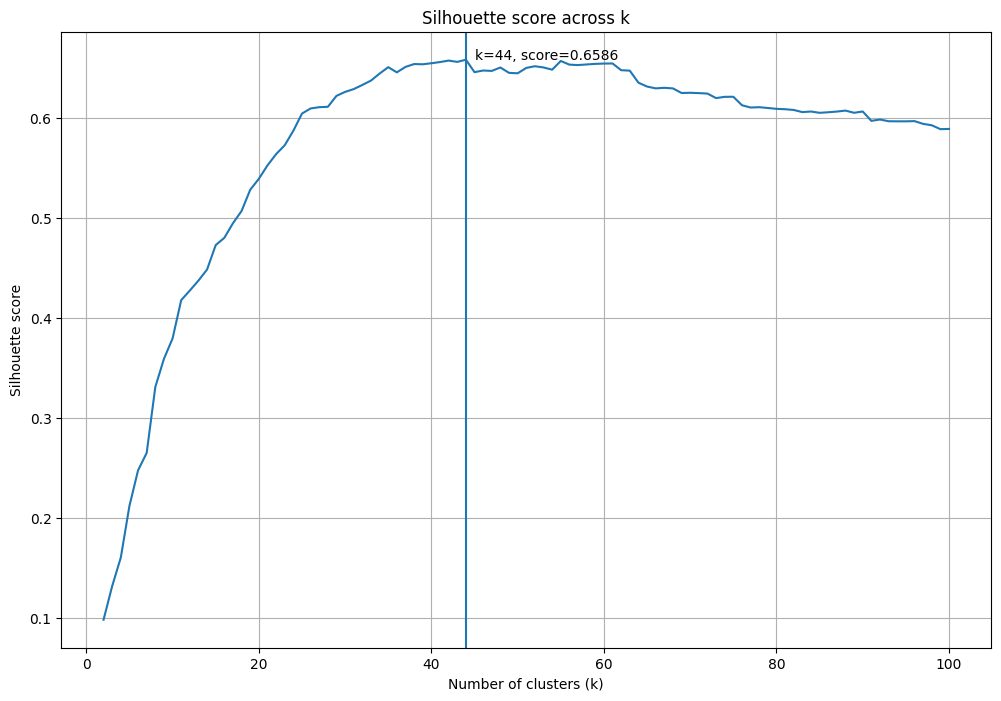

In [69]:
X = all_embeddings.numpy()

num_potential_clusters = 100

all_scores = []

for k in range(2, num_potential_clusters+1):
    kmeans = KMeans(n_clusters=k, random_state=7)
    pred_labels = kmeans.fit_predict(X)
    all_scores.append(silhouette_score(X, pred_labels))

ks = list(range(2, num_potential_clusters+1))
scores = np.array(all_scores)

best_idx = scores.argmax()
best_k = ks[best_idx]
best_score = scores[best_idx]

plt.figure(figsize=(12, 8))
plt.plot(ks, scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score across k")
plt.grid(True)
plt.axvline(best_k)
plt.annotate(
    f"k={best_k}, score={best_score:.4f}",
    xy=(best_k, best_score),
    xytext=(best_k + 1, best_score),
)
plt.show()

In [70]:
X = all_embeddings.numpy()
kmeans = KMeans(n_clusters=40, random_state=7)
labels = kmeans.fit_predict(X)
annotations_df["cluster"] = labels

clusters = annotations_df['cluster'].unique()
cluster2cat = {c: annotations_df[annotations_df['cluster']==c]['mention'].tolist() for c in clusters}
sorted_dict = dict(sorted(cluster2cat.items()))

centroids = kmeans.cluster_centers_

# distance of each point to its assigned centroid
distances = np.linalg.norm(X - centroids[labels], axis=1)

annotations_df["distance_to_centroid"] = distances

In [71]:
top10_per_cluster = annotations_df.sort_values(["cluster", "distance_to_centroid"]).groupby("cluster").head(10)
cluster_to_top_mentions = top10_per_cluster.groupby("cluster")["mention"].apply(list).to_dict()
cluster_to_top_mentions

{0: ['these children',
  'these children',
  'child',
  'child',
  'child',
  'child',
  'child',
  'child',
  'child',
  'child'],
 1: ['young people',
  'young people',
  'young people',
  'young people',
  'young people',
  'young people',
  'young people',
  'young people',
  'young people',
  'young people'],
 2: ['learners',
  'learners',
  'those students',
  'those students',
  'the students',
  'student',
  'student',
  'student',
  'student',
  'student'],
 3: ['those nurses',
  'nurses',
  'nurses',
  'nurses',
  'nurses',
  'nurses',
  'nurses',
  'nurses',
  'nurses',
  'nurses'],
 4: ['perpetrators',
  'perpetrators',
  'perpetrators',
  'perpetrators',
  'perpetrators',
  'perpetrators',
  'perpetrators',
  'perpetrators',
  'perpetrators',
  'the perpetrators'],
 5: ['families',
  'families',
  'Families',
  'families',
  'families',
  'families',
  'families',
  'families',
  'families',
  'families'],
 6: ['minorities',
  'persecuted Christians',
  'paedophiles',
  'p

In [34]:
cluster_labelling = {
    0: "Children", 1: "Students and practical learners", 2: "Perpetrators", 3: "Health professionals", 4: "Vulnerable people", 5: "Families", 6: "Military personnel", 7: "Unemployed", 8: "White collar workers", 9: "Criminals",
    10: "Patients", 11: "Civil servants", 12: "Local people", 13: "Employers and business owners", 14: "Employees and workers", 15: "Elderly people", 16: "People with disabilities", 17: "Education professionals", 18: "Consumers", 19: "Migrants and refugees",
    20: "Scottish, Irish, Northern Irish and Welsh people", 21: "Women", 22: "Students and practical learners", 23: "Men", 24: "Farmers", 25: "Lower class", 26: "Constituents", 27: "Law-enforcement personnel", 28: "Crime victims", 29: "Taxpayers",
    30: "Manual and service workers", 31: "Sociocultural professionals", 32: "Young people", 33: "British people", 34: "Road users", 35: "Homeowners and landowners", 36: "Religious communities", 37: "Tenants", 38: "Homeless people", 39: "Adults"
}

# apply these labels to the df
annotations_df["cluster_label"] = annotations_df["cluster"].map(cluster_labelling)

# reduce df to only the dictionary matches
annotations_df_dict = annotations_df[annotations_df["in_dictionary"] == True]

# run classification report
cr_annotations = classification_report(annotations_df_dict["category"], annotations_df_dict["cluster_label"])
print(cr_annotations)

                                                  precision    recall  f1-score   support

                                          Adults       1.00      0.86      0.92         7
                                  British people       0.00      0.00      0.00         0
                                      Caregivers       0.00      0.00      0.00         2
                                        Children       0.99      0.88      0.93       387
                                  Civil servants       0.45      1.00      0.62        14
                                       Consumers       1.00      0.85      0.92        46
                                   Crime victims       0.95      1.00      0.97       109
                                       Criminals       0.98      0.99      0.99       130
                         Education professionals       0.98      1.00      0.99        56
                                  Elderly people       0.89      0.96      0.93        53
         

/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control

In [72]:
contingency = pd.crosstab(
    annotations_df_dict["category"], annotations_df_dict["cluster"]
)
category_purity = contingency.max(axis=1) / contingency.sum(axis=1)
cluster_homogeneity = contingency.max(axis=0) / contingency.sum(axis=0)
np.mean(category_purity)

0.9369718365660281

In [76]:
nmi = normalized_mutual_info_score(
    annotations_df_dict["category"],
    annotations_df_dict["cluster"]
)

ari = adjusted_rand_score(
    annotations_df_dict["category"],
    annotations_df_dict["cluster"]
)
nmi

0.8890584665675656